In [23]:

import pandas as pd

In [24]:
df1 = pd.DataFrame({
    "acc" : [1,2,3],
    "name" : ["Ravi", "Hari", "Javi"],
    "age" : [11,12,22]
})

In [25]:
df1

,acc,name,age
0,1,Ravi,11
1,2,Hari,12
2,3,Javi,22


In [26]:
df2 = pd.DataFrame({
    "acc" : [5,6,7],
    "loan" : [44,55,66]
})

In [27]:
df2

,acc,loan
0,5,44
1,6,55
2,7,66


# concatination

In [28]:
row_contact = pd.concat([df1,df2], axis = 0)

In [29]:
row_contact

,acc,name,age,loan
0,1,Ravi,11.0,NaN
1,2,Hari,12.0,NaN
2,3,Javi,22.0,NaN
0,5,NaN,NaN,44.0
1,6,NaN,NaN,55.0
2,7,NaN,NaN,66.0


In [30]:
column_concat = pd.concat([df1,df2], axis = 1)
column_concat

,acc,name,age,acc,loan
0,1,Ravi,11,5,44
1,2,Hari,12,6,55
2,3,Javi,22,7,66


# Merge
# Merging is the process of combining two or more dataframes based on common columns

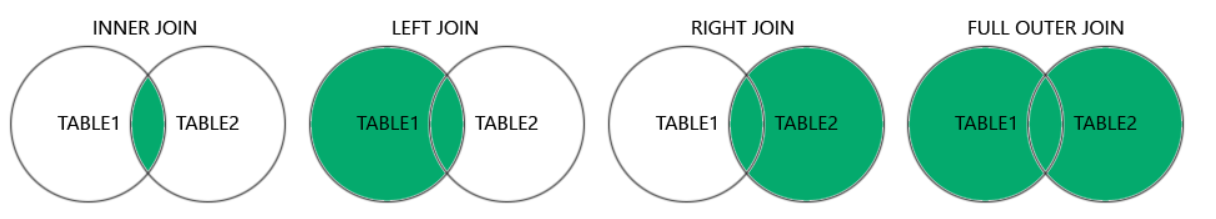

In [31]:
students = pd.DataFrame({
    "student_id" : [1,2,3,4,5],
    "name" : ["Ravi", "Hari", "Javi", "Jack" , "Mack"]
})

In [32]:
marks = pd.DataFrame({
    "student_id" : [1,2,3,6,7],
    "marks" : [44,55,66,77,88]
})

In [33]:
inner_merge = pd.merge(
    marks,
    students,
    on="student_id",
    how="inner"
)

print(inner_merge)

   student_id  marks  name
0           1     44  Ravi
1           2     55  Hari
2           3     66  Javi


# Join in pandas
Joining is similar to merging, but is specifically used to combine dataframes based on their indexes. You can use the pd.DataFrame.join() method to join dataframes.


In [34]:
df1 = pd.DataFrame({
    "key" : ["a", "b", "c", "d"],
    "value" : [1,2,3,4],
    "acc" : [1,2,3,4]
})

In [35]:
df1 = df1.set_index("key")

In [36]:
df1

,value,acc
key,,
a,1,1
b,2,2
c,3,3
d,4,4


In [37]:
df2 = pd.DataFrame({
    "key" : ["c", "d", "e","f"],
    "hel_ration" : [66,56,67,33],
    "acc" : [5,6,7,8]
})

In [38]:
df2 = df2.set_index("key")

In [39]:
df2

,hel_ration,acc
key,,
c,66,5
d,56,6
e,67,7
f,33,8


In [40]:
df1.join(df2,how="inner", lsuffix="_x" )

,value,acc_x,hel_ration,acc
key,,,,
c,3,3,66,5
d,4,4,56,6


In [41]:
df1.join(df2, how ="outer", rsuffix="_2")

,value,acc,hel_ration,acc_2
key,,,,
a,1.0,1.0,NaN,NaN
b,2.0,2.0,NaN,NaN
c,3.0,3.0,66.0,5.0
d,4.0,4.0,56.0,6.0
e,NaN,NaN,67.0,7.0
f,NaN,NaN,33.0,8.0


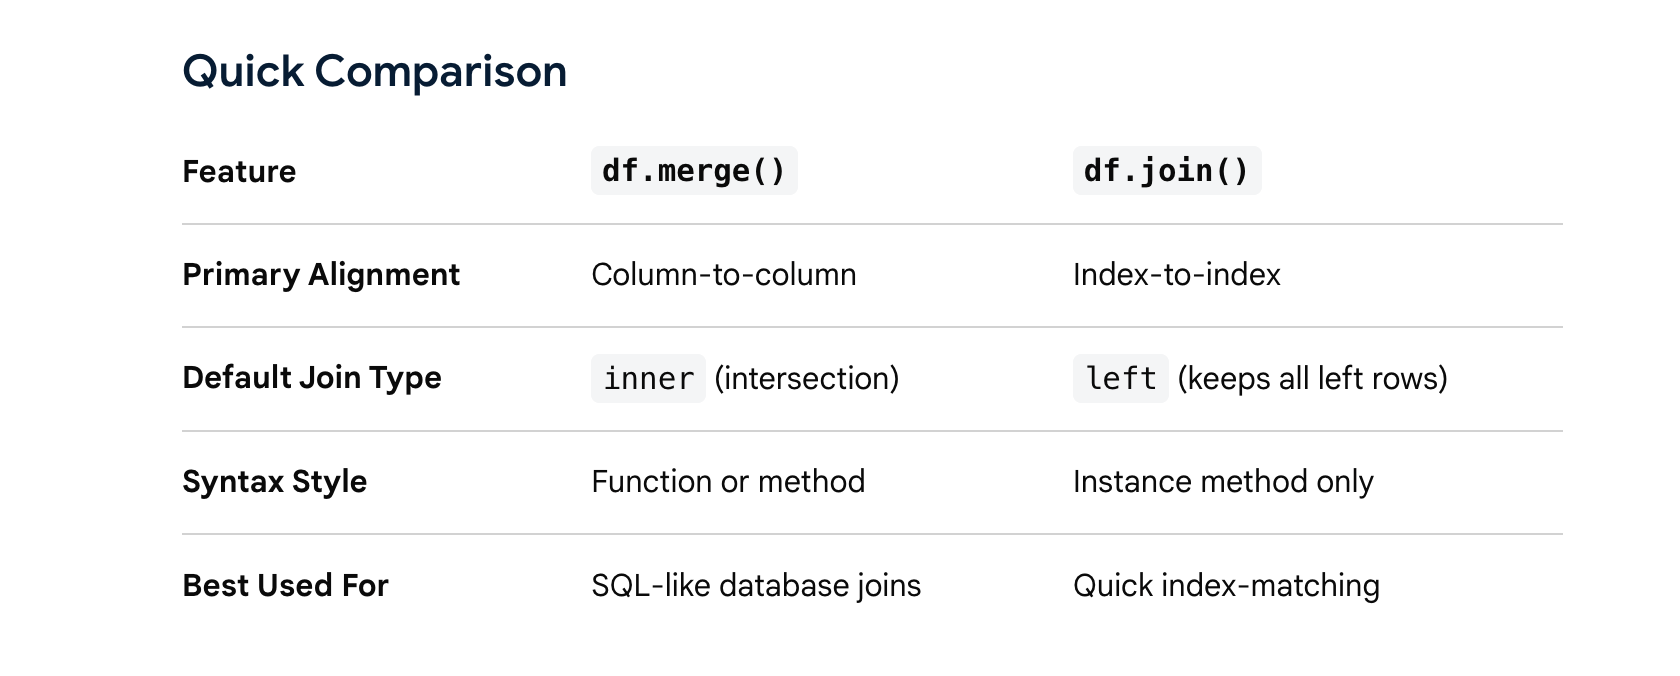

#Stacking

Stacking is the process of vertically combining datasets with the same columns. The datasets are aligned by their column names and then stacked on top of each other. You can use the dataframe.stack() function to stack a dataframe.

In [42]:
df1 = pd.DataFrame({
    "key" : ["a", "b", "c", "d"],
    "value" : [1,2,3,4],
    "acc" : [1,2,3,4]
}, index = ["w","x","y","z"])

In [43]:
df2 = pd.DataFrame({
    "key" : ["c", "d", "e","f"],
    "hel_ration" : [66,56,67,33],
    "acc" : [5,6,7,8]
})

In [44]:
stacked = df1.stack()
stacked

w  key      a
   value    1
   acc      1
x  key      b
   value    2
   acc      2
y  key      c
   value    3
   acc      3
z  key      d
   value    4
   acc      4
dtype: object

Real-world example

Imagine an e-commerce company:

January sales + February sales → concat()

Customers + Orders using Customer_ID → merge()

Sales data + customer information using index → join()

Monthly columns → individual month rows → stack()

One important correction: calling all four "data integration" is slightly misleading. concat, merge, and join are primarily data-combination/integration operations; stack() is primarily a data reshaping operation.

#Encoding

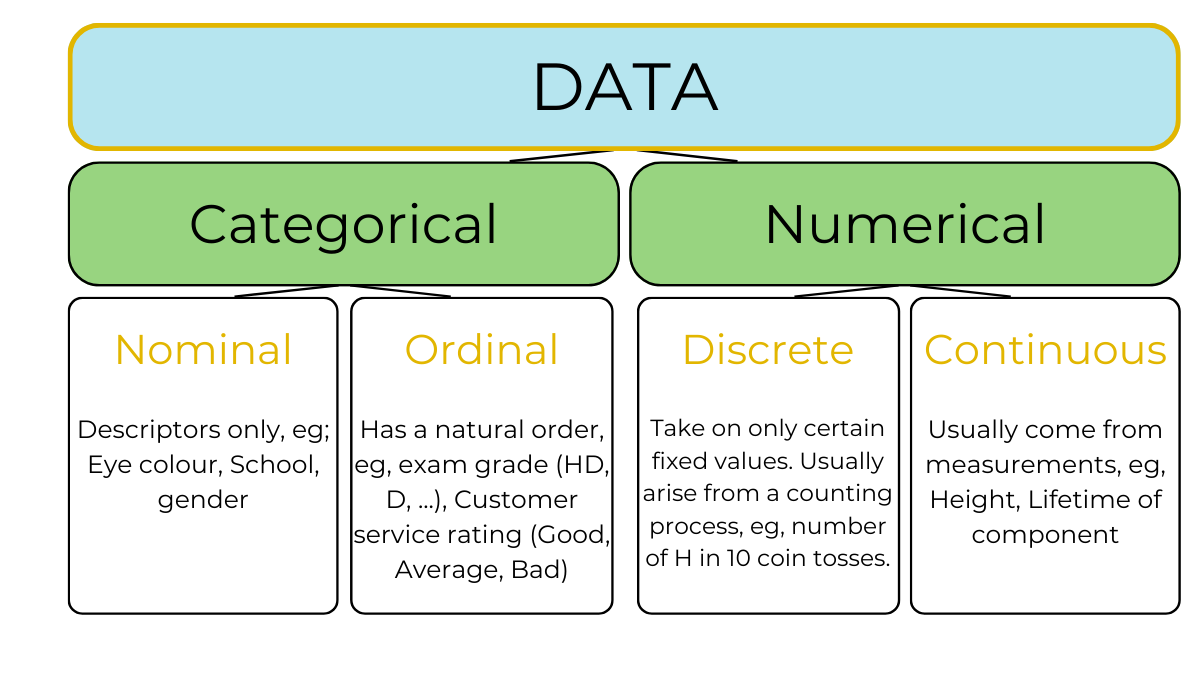

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
titanic_df = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning/titanic-data.csv")

In [47]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
titanic_df["Sex"]

,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


In [49]:
pd.get_dummies(titanic_df, columns=["Sex"], dtype=int)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,0,1


In [50]:
pd.get_dummies(titanic_df, columns = ["Embarked"], dtype= int)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,1,0,0
